# Multivariate Linear Regression — Q-CHAT-10 Toddler Autism Screening

**Mission:** predict the Q-CHAT-10 screening score from behavioral answers (A1-A10) and demographics,
to help underserved families and clinics get quick severity estimates without waiting for a specialist.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import joblib

sns.set_style('whitegrid')

## 1. Load data

In [2]:
df = pd.read_csv('Toddler Autism dataset July 2018.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1054 entries, 0 to 1053
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Case_No                 1054 non-null   int64
 1   A1                      1054 non-null   int64
 2   A2                      1054 non-null   int64
 3   A3                      1054 non-null   int64
 4   A4                      1054 non-null   int64
 5   A5                      1054 non-null   int64
 6   A6                      1054 non-null   int64
 7   A7                      1054 non-null   int64
 8   A8                      1054 non-null   int64
 9   A9                      1054 non-null   int64
 10  A10                     1054 non-null   int64
 11  Age_Mons                1054 non-null   int64
 12  Qchat-10-Score          1054 non-null   int64
 13  Sex                     1054 non-null   str  
 14  Ethnicity               1054 non-null   str  
 15  Jaundice                1054 non

In [3]:
df.isnull().sum()

Case_No                   0
A1                        0
A2                        0
A3                        0
A4                        0
A5                        0
A6                        0
A7                        0
A8                        0
A9                        0
A10                       0
Age_Mons                  0
Qchat-10-Score            0
Sex                       0
Ethnicity                 0
Jaundice                  0
Family_mem_with_ASD       0
Who completed the test    0
Class/ASD Traits          0
dtype: int64

## 2. Drop leakage / non-predictive columns

In [4]:
df = df.drop(columns=['Case_No', 'Who completed the test', 'Class/ASD Traits '])
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD
0,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no
1,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no
2,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no
3,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no
4,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes


## 3. Correlation heatmap and distributions

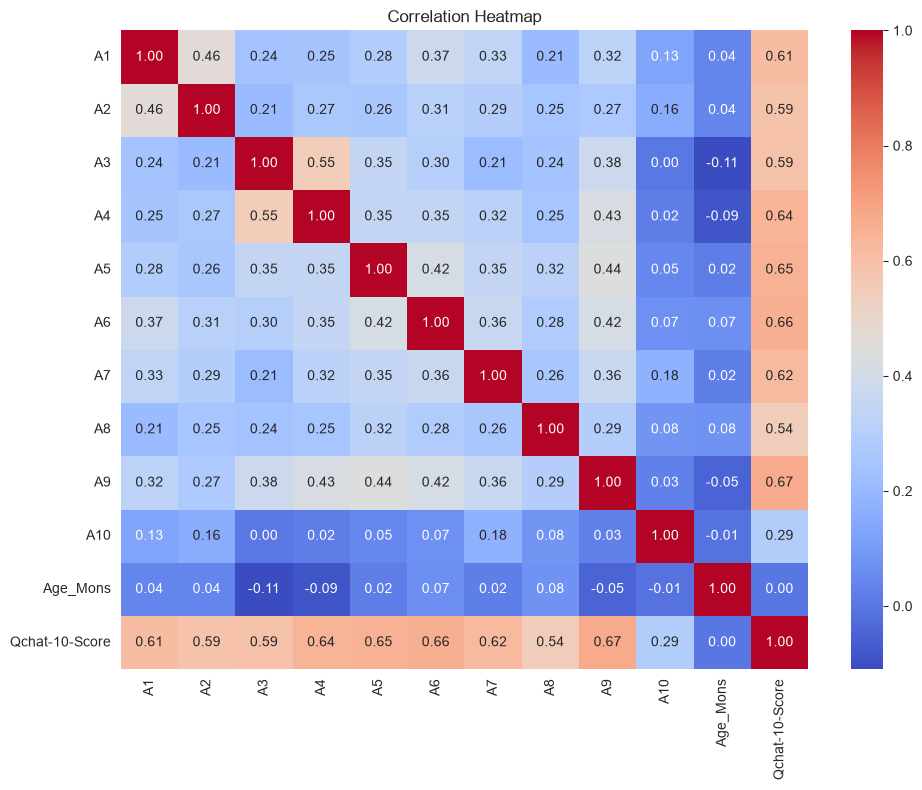

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

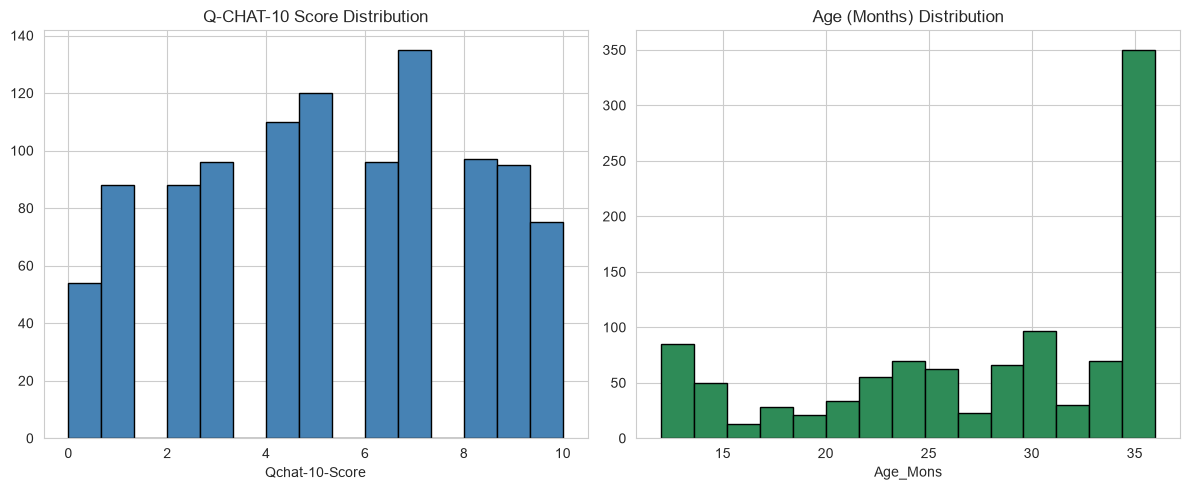

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df['Qchat-10-Score'], bins=15, color='steelblue', edgecolor='black')
axes[0].set_title('Q-CHAT-10 Score Distribution')
axes[0].set_xlabel('Qchat-10-Score')
axes[1].hist(df['Age_Mons'], bins=15, color='seagreen', edgecolor='black')
axes[1].set_title('Age (Months) Distribution')
axes[1].set_xlabel('Age_Mons')
plt.tight_layout()
plt.savefig('histograms.png')
plt.show()

## 4. Label-encode categorical columns

In [7]:
encoders = {}
for col in ['Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD
0,0,0,0,0,0,0,1,1,0,1,28,3,0,8,1,0
1,1,1,0,0,0,1,1,0,0,0,36,4,1,5,1,0
2,1,0,0,0,0,0,1,1,0,1,36,4,1,8,1,0
3,1,1,1,1,1,1,1,1,1,1,24,10,1,0,0,0
4,1,1,0,1,1,1,1,1,1,1,20,9,0,5,0,1


## 5. Train/test split and feature scaling

In [8]:
X = df.drop(columns=['Qchat-10-Score'])
y = df['Qchat-10-Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Train models

In [9]:
models = {}

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
models['LinearRegression'] = lr

In [10]:
sgd = SGDRegressor(max_iter=1, learning_rate='invscaling', eta0=0.01, random_state=42, warm_start=True)
epochs = 200
train_mse_history = []
test_mse_history = []

for epoch in range(epochs):
    sgd.partial_fit(X_train_scaled, y_train)
    train_mse_history.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_mse_history.append(mean_squared_error(y_test, sgd.predict(X_test_scaled)))

models['SGDRegressor'] = sgd

In [11]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, y_train)
models['DecisionTreeRegressor'] = dt

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)
models['RandomForestRegressor'] = rf

## 7. SGD train vs test loss curve

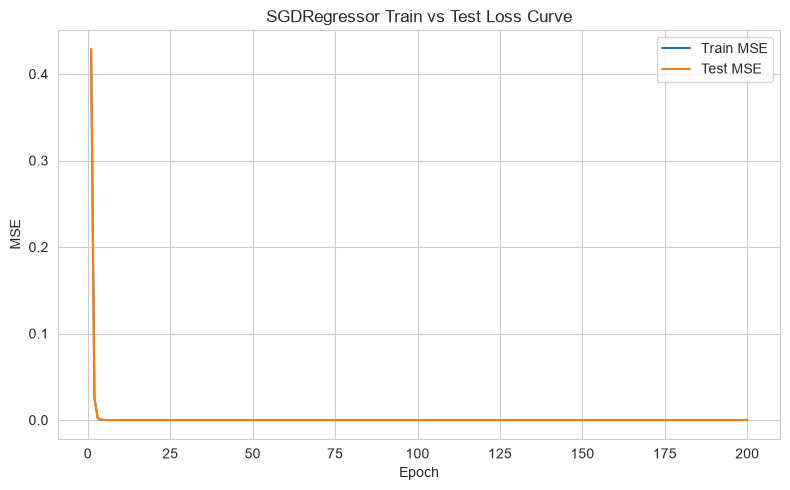

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_mse_history, label='Train MSE')
plt.plot(range(1, epochs + 1), test_mse_history, label='Test MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('SGDRegressor Train vs Test Loss Curve')
plt.legend()
plt.tight_layout()
plt.savefig('sgd_loss_curve.png')
plt.show()

## 8. Age_Mons vs Q-CHAT-10 Score — before and after a simple linear fit

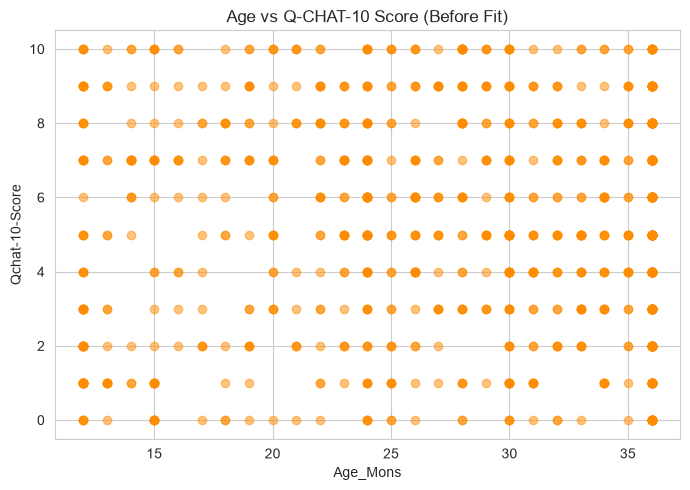

In [13]:
plt.figure(figsize=(7, 5))
plt.scatter(df['Age_Mons'], df['Qchat-10-Score'], alpha=0.5, color='darkorange')
plt.xlabel('Age_Mons')
plt.ylabel('Qchat-10-Score')
plt.title('Age vs Q-CHAT-10 Score (Before Fit)')
plt.tight_layout()
plt.savefig('age_vs_qchat_before.png')
plt.show()

C:\Users\divin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


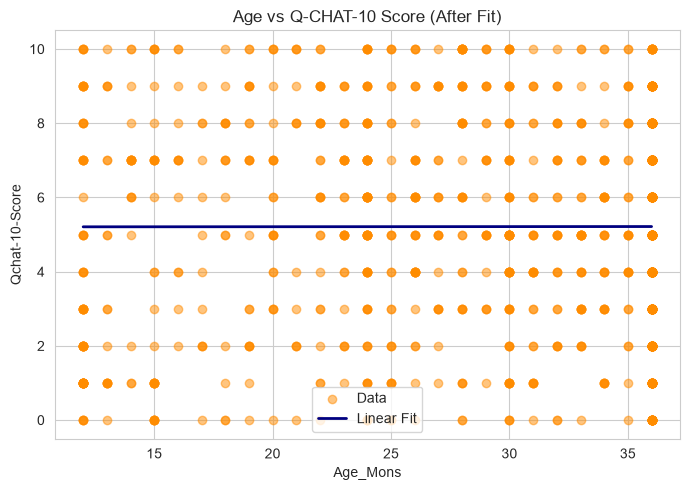

In [14]:
age_X = df[['Age_Mons']]
age_y = df['Qchat-10-Score']
age_lr = LinearRegression()
age_lr.fit(age_X, age_y)

x_range = np.linspace(age_X.values.min(), age_X.values.max(), 100).reshape(-1, 1)

plt.figure(figsize=(7, 5))
plt.scatter(df['Age_Mons'], df['Qchat-10-Score'], alpha=0.5, color='darkorange', label='Data')
plt.plot(x_range, age_lr.predict(x_range), color='navy', linewidth=2, label='Linear Fit')
plt.xlabel('Age_Mons')
plt.ylabel('Qchat-10-Score')
plt.title('Age vs Q-CHAT-10 Score (After Fit)')
plt.legend()
plt.tight_layout()
plt.savefig('age_vs_qchat_after.png')
plt.show()

## 9. Compare models

In [15]:
mse_scores = {}
for name, model in models.items():
    pred = model.predict(X_test_scaled)
    mse_scores[name] = mean_squared_error(y_test, pred)
    print(f'{name}: Test MSE = {mse_scores[name]:.4f}')

best_model_name = min(mse_scores, key=mse_scores.get)
best_model = models[best_model_name]
print(f'\nBest model: {best_model_name} (Test MSE = {mse_scores[best_model_name]:.4f})')

LinearRegression: Test MSE = 0.0000
SGDRegressor: Test MSE = 0.0000
DecisionTreeRegressor: Test MSE = 0.6682
RandomForestRegressor: Test MSE = 0.1094

Best model: LinearRegression (Test MSE = 0.0000)
